In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path.cwd().parent / "data"
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
DEPOTS = ["Peliyagoda", "Kandy"]
TRUCK, VAN = "#eb6834", "#eda100"
PAIR_COLOR = "#2a78d6"
TOTAL_VOL, CHILLED_VOL = "#2a78d6", "#1baf7a"
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "font.size": 10,
})

In [2]:
vehicles = pd.read_csv(DATA / "General Data/vehicles.csv").rename(columns=str.strip)
orders = pd.concat([pd.read_csv(DATA / "Training Data/deliveries_train.csv"),
                    pd.read_csv(DATA / "Test Data/task1_test_inputs.csv")], ignore_index=True)
legs = pd.concat([pd.read_csv(DATA / "Training Data/route_legs_train.csv"),
                  pd.read_csv(DATA / "Test Data/route_legs_test.csv")], ignore_index=True)

In [3]:
ran = orders[orders.dispatch_status == "attempted"]
routes = ran.groupby("route_id").agg(
    date=("dispatch_date", "first"), vehicle_id=("vehicle_id", "first"), depot=("depot", "first"),
    brand=("brand", "first"), n_brands=("brand", "nunique"),
    n_chilled=("temp_requirement", lambda s: (s == "chilled").sum()), n_orders=("delivery_id", "size"),
    first_arrival=("planned_arrival_time", "min"))
routes["cargo"] = np.select([routes.n_chilled == 0, routes.n_chilled == routes.n_orders], ["dry", "chilled"], "mixed")
start = legs[legs.seq == 0].drop_duplicates("route_id").set_index("route_id").planned_depart_time
routes["start"] = start.reindex(routes.index).fillna(routes.first_arrival)
routes["date"] = pd.to_datetime(routes.date)
routes["dow"] = routes.date.dt.dayofweek
routes = routes.reset_index()
print(f"{len(routes):,} routes; routes carrying more than one brand: {(routes.n_brands > 1).sum()}; "
      f"cargo: {routes.cargo.value_counts().to_dict()}")

26,551 routes; routes carrying more than one brand: 0; cargo: {'dry': 16316, 'chilled': 10235}


Peliyagoda: all 7 reefer trucks used on 498 days, all 2 reefer vans on 0 days, both on 0 days (of 695)
Kandy: all 5 reefer trucks used on 100 days, all 2 reefer vans on 2 days, both on 0 days (of 695)


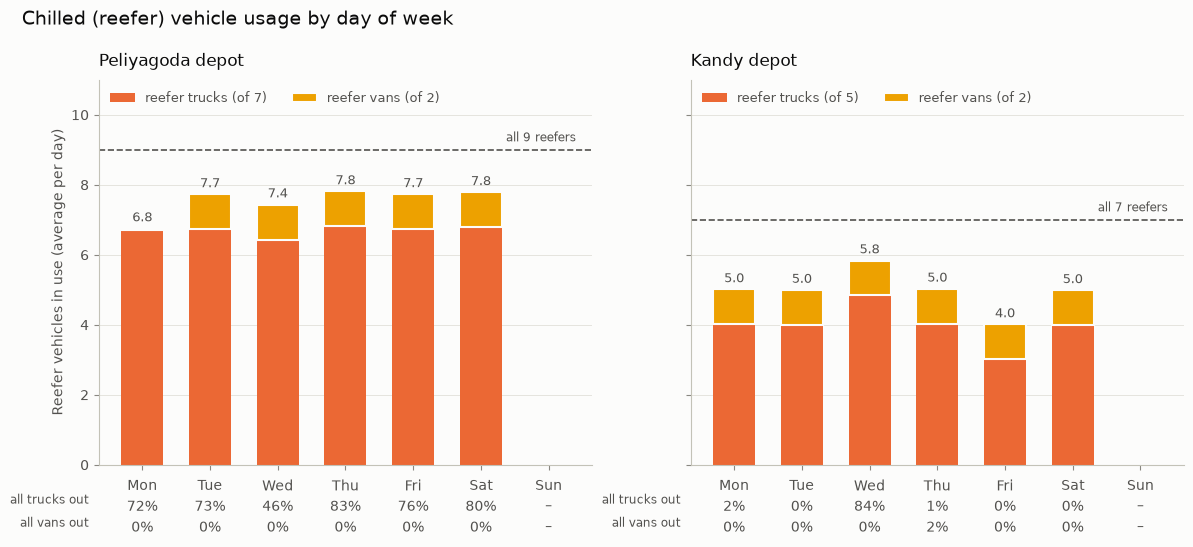

,depot,day,trucks,of_trucks,vans,of_vans,days_all_trucks_used,days_all_vans_used
0,Peliyagoda,Mon,6.71,7,0.04,2,72%,0%
1,Peliyagoda,Tue,6.72,7,1.00,2,73%,0%
2,Peliyagoda,Wed,6.43,7,1.00,2,46%,0%
3,Peliyagoda,Thu,6.81,7,1.00,2,83%,0%
4,Peliyagoda,Fri,6.74,7,0.99,2,76%,0%
5,Peliyagoda,Sat,6.78,7,1.00,2,80%,0%
6,Kandy,Mon,4.01,5,1.00,2,2%,0%
7,Kandy,Tue,3.99,5,1.00,2,0%,0%
8,Kandy,Wed,4.84,5,0.99,2,84%,0%
9,Kandy,Thu,4.01,5,1.02,2,1%,2%


In [4]:
reefers = vehicles[vehicles.temp == "reefer"].set_index("vehicle_id")
used = routes[routes.vehicle_id.isin(reefers.index)].drop_duplicates(["date", "vehicle_id"])
used = used.assign(type=used.vehicle_id.map(reefers.type))
all_days = routes[["date", "dow"]].drop_duplicates()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
table = []
for ax, depot in zip(axes, DEPOTS):
    fleet = reefers[reefers.depot == depot]
    n_truck, n_van = (fleet.type == "truck").sum(), (fleet.type == "van").sum()
    per_day = (used[used.depot == depot].groupby(["date", "type"]).size().unstack(fill_value=0)
               .reindex(columns=["truck", "van"], fill_value=0).reindex(all_days.date, fill_value=0))
    per_day["dow"] = all_days.set_index("date").dow.reindex(per_day.index).values
    avg = per_day.groupby("dow")[["truck", "van"]].mean().reindex(range(7))
    full = (per_day.truck == n_truck).groupby(per_day.dow).mean().reindex(range(7))
    full_van = (per_day.van == n_van).groupby(per_day.dow).mean().reindex(range(7))
    print(f"{depot}: all {n_truck} reefer trucks used on {(per_day.truck == n_truck).sum()} days, "
          f"all {n_van} reefer vans on {(per_day.van == n_van).sum()} days, "
          f"both on {((per_day.truck == n_truck) & (per_day.van == n_van)).sum()} days (of {len(per_day)})")
    x = np.arange(7)
    ax.bar(x, avg.truck.fillna(0), color=TRUCK, width=0.62, label=f"reefer trucks (of {n_truck})")
    ax.bar(x, avg.van.fillna(0), bottom=avg.truck.fillna(0), color=VAN, width=0.62,
           edgecolor=SURFACE, linewidth=1.5, label=f"reefer vans (of {n_van})")
    ax.axhline(n_truck + n_van, color=INK_2, lw=1.2, ls="--")
    ax.annotate(f"all {n_truck + n_van} reefers", (6.4, n_truck + n_van), xytext=(0, 4),
                textcoords="offset points", ha="right", va="bottom", fontsize=8.5, color=INK_2)
    for xi, (t, v) in enumerate(zip(avg.truck, avg.van)):
        if t == t:
            ax.text(xi, t + v + 0.12, f"{t + v:.1f}", ha="center", va="bottom", fontsize=9, color=INK_2)
    ax.set_xticks(x, [f"{day}\n{f:.0%}\n{fv:.0%}" if f == f else f"{day}\n–\n–"
                      for day, f, fv in zip(DAYS, full, full_van)], linespacing=1.5)
    ax.text(-0.02, -0.075, "all trucks out", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=INK_2)
    ax.text(-0.02, -0.135, "all vans out", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=INK_2)
    ax.grid(axis="x", visible=False)
    ax.set_title(f"{depot} depot")
    ax.legend(frameon=False, loc="upper left", labelcolor=INK_2, fontsize=9, ncol=2)
    for d in range(6):
        table.append(dict(depot=depot, day=DAYS[d], trucks=round(avg.truck.iloc[d], 2), of_trucks=n_truck,
                          vans=round(avg.van.iloc[d], 2), of_vans=n_van,
                          days_all_trucks_used=f"{full.iloc[d]:.0%}", days_all_vans_used=f"{full_van.iloc[d]:.0%}"))
axes[0].set_ylabel("Reefer vehicles in use (average per day)")
axes[0].set_ylim(0, 11)
fig.suptitle("Chilled (reefer) vehicle usage by day of week", x=0.07, ha="left", fontsize=14, color=INK, y=1.02)
plt.show()
pd.DataFrame(table)

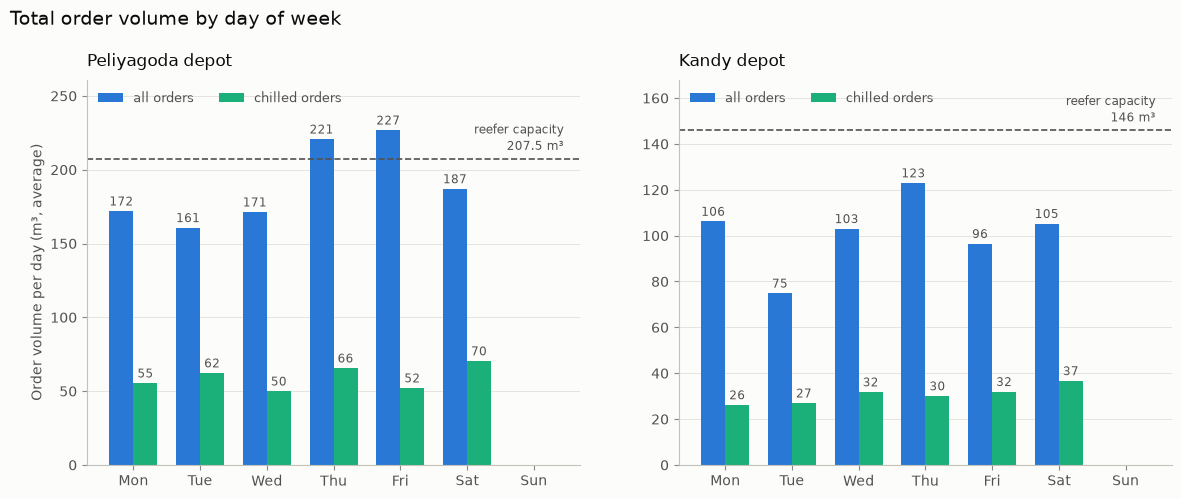

,depot,day,all_m3,chilled_m3,reefer_cap_m3,chilled_share_of_reefer_cap
0,Peliyagoda,Mon,171.9,55.4,207.5,27%
1,Peliyagoda,Tue,160.7,62.3,207.5,30%
2,Peliyagoda,Wed,171.3,49.9,207.5,24%
3,Peliyagoda,Thu,220.7,65.5,207.5,32%
4,Peliyagoda,Fri,226.8,52.1,207.5,25%
5,Peliyagoda,Sat,187.0,70.4,207.5,34%
6,Kandy,Mon,106.2,26.2,146.0,18%
7,Kandy,Tue,74.9,27.0,146.0,18%
8,Kandy,Wed,103.0,31.8,146.0,22%
9,Kandy,Thu,123.0,30.1,146.0,21%


In [5]:
o = orders.assign(date=pd.to_datetime(orders.order_date))
o["dow"] = o.date.dt.dayofweek
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
table = []
for ax, depot in zip(axes, DEPOTS):
    d = o[o.depot == depot]
    daily_all = d.groupby(["date", "dow"]).order_volume_m3.sum()
    daily_chilled = (d[d.temp_requirement == "chilled"].groupby(["date", "dow"]).order_volume_m3.sum()
                     .reindex(daily_all.index, fill_value=0))
    avg_all = daily_all.groupby("dow").mean().reindex(range(7))
    avg_chilled = daily_chilled.groupby("dow").mean().reindex(range(7))
    reefer_cap = vehicles[(vehicles.depot == depot) & (vehicles.temp == "reefer")].volume_cap_m3.sum()
    x = np.arange(7)
    b1 = ax.bar(x - 0.18, avg_all.fillna(0), width=0.36, color=TOTAL_VOL, label="all orders")
    b2 = ax.bar(x + 0.18, avg_chilled.fillna(0), width=0.36, color=CHILLED_VOL, label="chilled orders")
    for bars, vals in [(b1, avg_all), (b2, avg_chilled)]:
        ax.bar_label(bars, labels=[f"{v:.0f}" if v == v else "" for v in vals], padding=2, fontsize=8.5, color=INK_2)
    ax.axhline(reefer_cap, color=INK_2, lw=1.2, ls="--")
    ax.annotate(f"reefer capacity\n{reefer_cap:g} m³", (6.45, reefer_cap), xytext=(0, 4), textcoords="offset points",
                ha="right", va="bottom", fontsize=8.5, color=INK_2, linespacing=1.3)
    ax.set_xticks(x, DAYS)
    ax.grid(axis="x", visible=False)
    ax.set_title(f"{depot} depot")
    ax.set_ylim(0, max(avg_all.max(), reefer_cap) * 1.15)
    ax.legend(frameon=False, loc="upper left", labelcolor=INK_2, fontsize=9, ncol=2)
    for dd in range(6):
        table.append(dict(depot=depot, day=DAYS[dd], all_m3=round(avg_all.iloc[dd], 1),
                          chilled_m3=round(avg_chilled.iloc[dd], 1), reefer_cap_m3=reefer_cap,
                          chilled_share_of_reefer_cap=f"{avg_chilled.iloc[dd] / reefer_cap:.0%}"))
axes[0].set_ylabel("Order volume per day (m³, average)")
fig.suptitle("Total order volume by day of week", x=0.07, ha="left", fontsize=14, color=INK, y=1.02)
plt.show()
pd.DataFrame(table)

Fresh routes per vehicle-day: {1: 16510, 2: 3294}
Vehicle-days with 2+ Fresh routes: 3,294 of 19,804 (28 different vehicles)


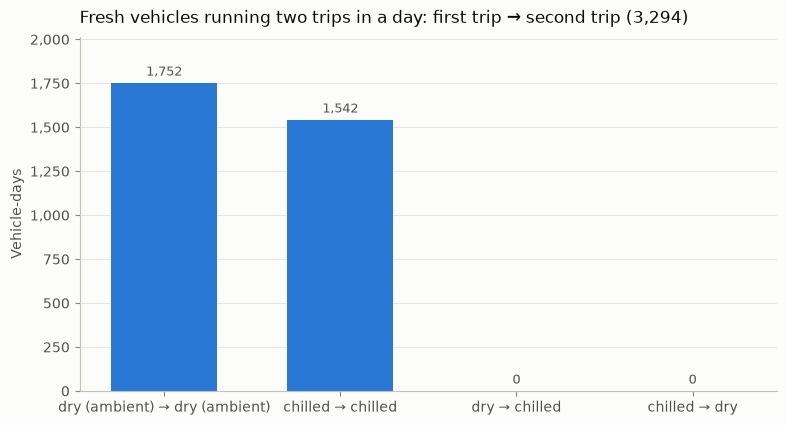

depot,Kandy,Peliyagoda,total
pair,,,
dry → dry,1021,731,1752
chilled → chilled,1086,456,1542
dry → chilled,0,0,0
chilled → dry,0,0,0


In [6]:
fresh = routes[routes.brand == "Fresh"].sort_values(["date", "vehicle_id", "start"])
per_vd = fresh.groupby(["date", "vehicle_id"]).size()
multi = per_vd[per_vd >= 2]
print(f"Fresh routes per vehicle-day: {per_vd.value_counts().sort_index().to_dict()}")
print(f"Vehicle-days with 2+ Fresh routes: {len(multi):,} of {len(per_vd):,} "
      f"({multi.index.get_level_values('vehicle_id').nunique()} different vehicles)")
f = fresh.set_index(["date", "vehicle_id"]).loc[multi.index].reset_index()
f["next_cargo"] = f.groupby(["date", "vehicle_id"]).cargo.shift(-1)
pairs = f.dropna(subset=["next_cargo"])
pairs = pairs.assign(pair=pairs.cargo + " → " + pairs.next_cargo)
order = ["dry → dry", "chilled → chilled", "dry → chilled", "chilled → dry"]
counts = pairs.groupby("pair").size()
order += [p for p in counts.index if p not in order]
counts = counts.reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.6))
x = np.arange(len(order))
bars = ax.bar(x, counts.values, color=PAIR_COLOR, width=0.6)
ax.bar_label(bars, labels=[f"{n:,}" for n in counts.values], padding=3, fontsize=9.5, color=INK_2)
ax.set_xticks(x, [p.replace("dry", "dry (ambient)") if p == "dry → dry" else p for p in order])
ax.grid(axis="x", visible=False)
ax.margins(y=0.15)
ax.set_ylabel("Vehicle-days")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.set_title(f"Fresh vehicles running two trips in a day: first trip → second trip ({counts.sum():,})")
plt.show()
pairs.groupby(["pair", "depot"]).size().unstack(fill_value=0).reindex(order, fill_value=0).assign(total=counts)

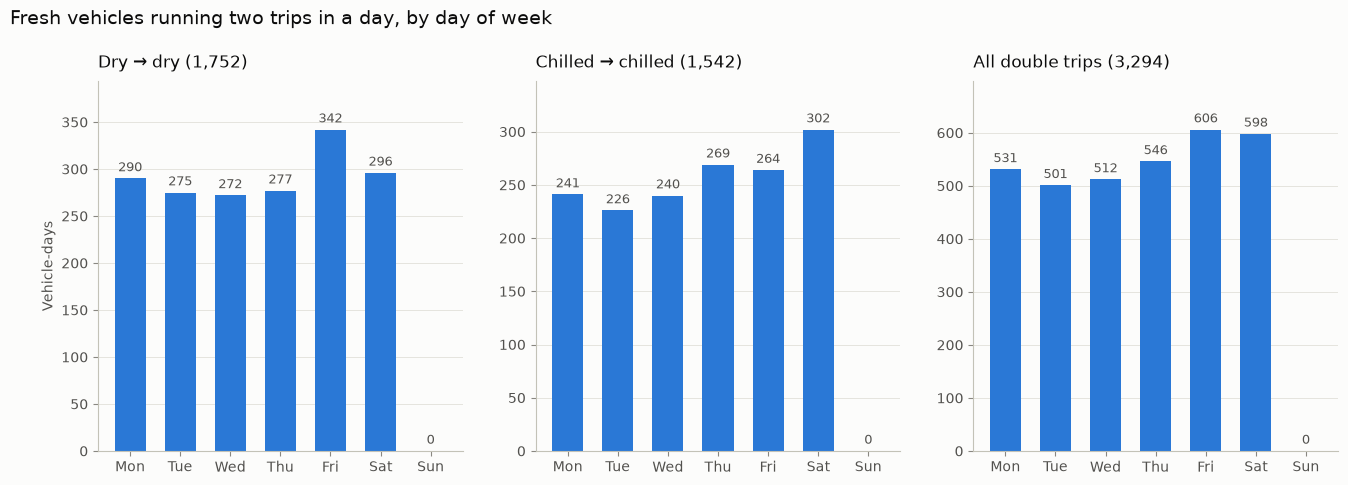

,Dry → dry,Chilled → chilled,All double trips
Mon,290,241,531
Tue,275,226,501
Wed,272,240,512
Thu,277,269,546
Fri,342,264,606
Sat,296,302,598
Sun,0,0,0


In [7]:
panels = [("Dry → dry", pairs[pairs.pair == "dry → dry"]),
          ("Chilled → chilled", pairs[pairs.pair == "chilled → chilled"]),
          ("All double trips", pairs)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
table = {}
for ax, (title, sub) in zip(axes, panels):
    counts = sub.groupby("dow").size().reindex(range(7), fill_value=0)
    table[title] = counts.values
    x = np.arange(7)
    bars = ax.bar(x, counts.values, color=PAIR_COLOR, width=0.62)
    ax.bar_label(bars, labels=[f"{n:,}" for n in counts.values], padding=3, fontsize=9, color=INK_2)
    ax.set_xticks(x, DAYS)
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.15)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.set_title(f"{title} ({counts.sum():,})")
axes[0].set_ylabel("Vehicle-days")
fig.suptitle("Fresh vehicles running two trips in a day, by day of week", x=0.07, ha="left", fontsize=14, color=INK, y=1.03)
plt.show()
pd.DataFrame(table, index=DAYS)